In [1]:
import platform
platform.platform()

'macOS-26.2-arm64-arm-64bit'

In [2]:
import sys
sys.version

'3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]'

In [3]:
import os
sys.path.append(os.path.abspath("../.."))

In [4]:
import matplotlib
matplotlib.__version__

'3.10.8'

In [5]:
import matplotlib.pyplot as plt
from matplotlib import patches

In [6]:
import numpy as np
np.__version__

'1.23.5'

In [7]:
import pandas as pd
pd.__version__

'2.3.3'

In [8]:
import scipy
scipy.__version__

'1.15.3'

In [9]:
from SSMetrics import metrics

In [10]:
df1 = pd.read_csv("../../1_dataset/1_28descriptors/3_PCA/pca.csv")
df1.shape

(4665, 39)

In [11]:
df1.columns

Index(['SMILES', 'InChI', 'InChIKey', 'K3FeCN6', 'MesAcr+BF4-', 'CuCl',
       'Diacetyl', 'T(p-OMe)PPCo', 'Electrode', 'm_1_L', 'm_1_B1', 'm_1_B5',
       'p_L', 'p_B1', 'p_B5', 'm_2_L', 'm_2_B1', 'm_2_B5', 'o_L', 'o_B1',
       'o_B5', 'Charge_O', 'Charge_next_O', 'Charge_o_1', 'Charge_m_1',
       'Charge_p', 'Charge_m_2', 'Charge_o_2', 'HOMO', 'MolLogP', 'MolWt',
       'num_N', 'num_O', 'num_S', 'num_F', 'num_Cl', 'num_Br', 'PC1', 'PC2'],
      dtype='object')

In [12]:
conditions = [["K3FeCN6",[(255/255, 75/255, 0/255)], "K$_3$[Fe(CN)$_6$]"],
              ["MesAcr+BF4-", [(153/255, 0/255, 153/255)], "MesAcr$^+$BF$_4^-$"],
              ["CuCl", [(3/255, 175/255, 122/255)], "CuCl"],
              ["Diacetyl", [(246/255, 170/255, 0/255)], "Diacetyl"],
              ["T(p-OMe)PPCo", [(77/255, 196/255, 255/255)], "T($p$-OMe)PPCo"],
              ["Electrode", [(255/255, 128/255, 130/255)], "Electrode"]]

In [13]:
li_numbers = []
li_convexhull = []

K3FeCN6
 0    4591
-1      51
 1      23
Name: count, dtype: int64

Area: 4.143508986474009


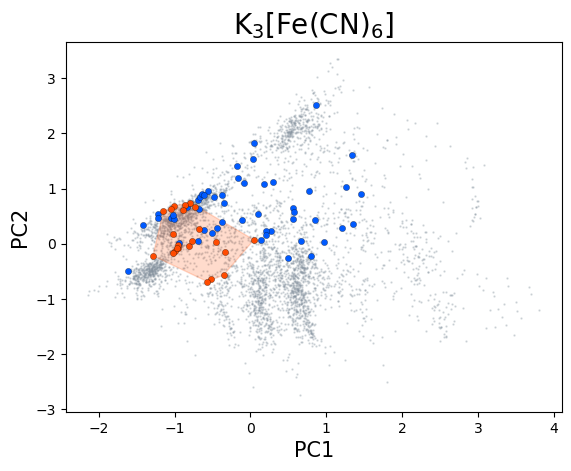

MesAcr+BF4-
0    4645
1      20
Name: count, dtype: int64

Area: 6.430956548009373


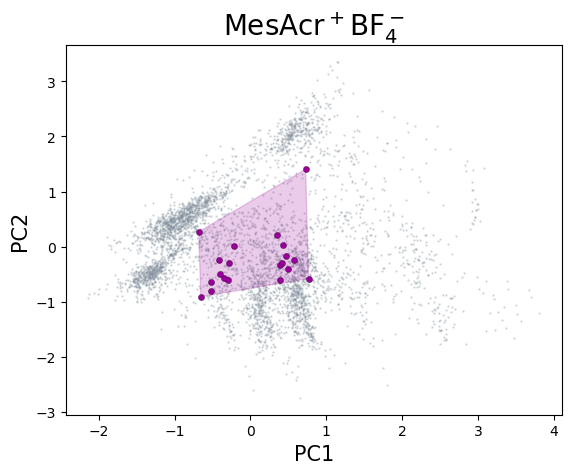

CuCl
0    4646
1      19
Name: count, dtype: int64

Area: 3.5159041614419904


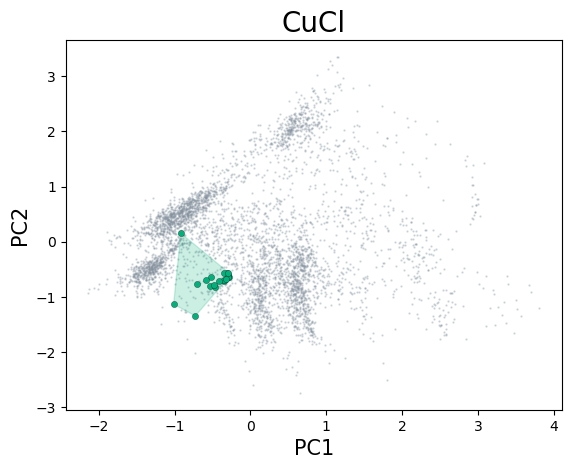

Diacetyl
0    4653
1      12
Name: count, dtype: int64

Area: 4.459198271740805


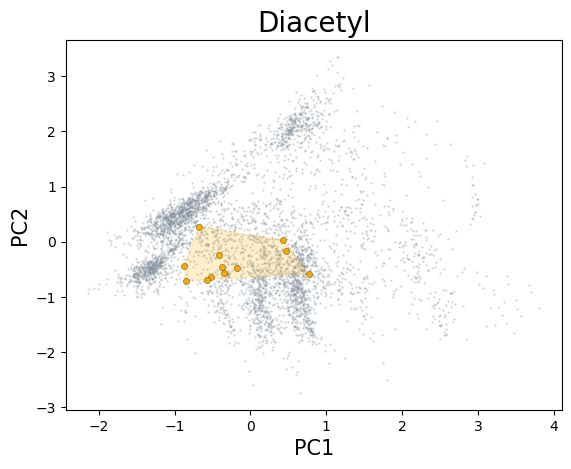

T(p-OMe)PPCo
0    4656
1       9
Name: count, dtype: int64

Area: 3.2207949846570436


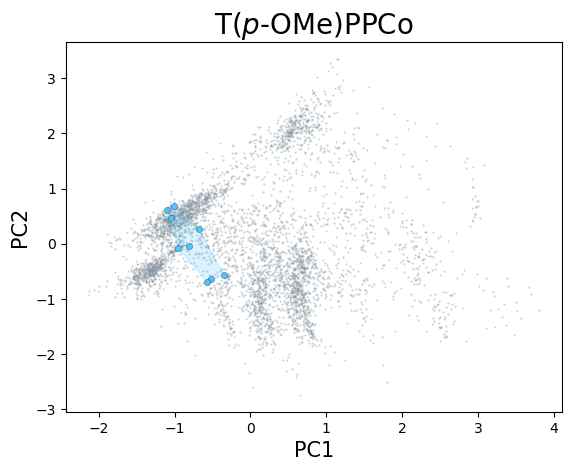

Electrode
0    4656
1       9
Name: count, dtype: int64

Area: 3.6293112028379553


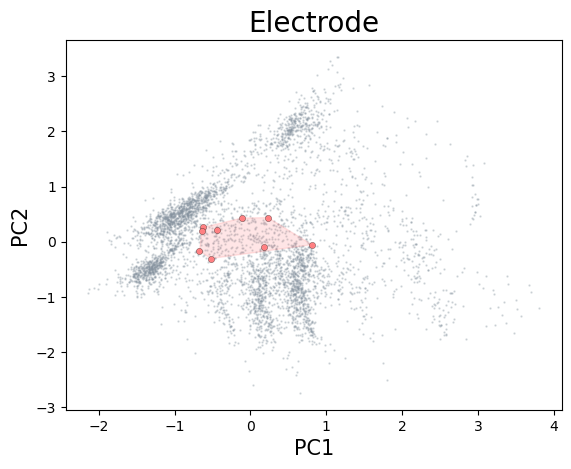

In [14]:
for i in range(6):
    condition = conditions[i][0]
    colour = conditions[i][1]
    title = conditions[i][2]

    print(df1[condition].value_counts())

    x_p = df1[df1[condition] == 1].PC1
    y_p = df1[df1[condition] == 1].PC2

    x_n = df1[df1[condition] == -1].PC1
    y_n = df1[df1[condition] == -1].PC2

    x_u = df1[df1[condition] == 0].PC1
    y_u = df1[df1[condition] == 0].PC2

    df2 = df1[df1[condition] == 1].loc[:, "PC1":"PC2"]
    li_numbers.append(len(df2))

    array2 = df2.to_numpy()

    area, vertices = metrics.metrics_ConvexHull(array2)
    li_convexhull.append(area)

    print(f"\nArea: {area}")

    fig = plt.figure()
    ax = fig.add_subplot()

    polygon = patches.Polygon(array2[vertices], closed=True, label="ConvexHull",
                              color=colour[0], alpha=0.2)

    if len(x_n) != 0:
        p1 = ax.scatter(x_u, y_u, label="Unlabeled",
                        s=2, c=[(132/255, 145/255, 158/255)], marker=".", alpha=0.3)
        p2 = ax.add_patch(polygon)
        p3 = ax.scatter(x_n, y_n, label="Negative",
                        s=20, c=[(0/255, 90/255, 255/255)], marker="o",
                        edgecolors="k", linewidths=0.2)
        p4 = ax.scatter(x_p, y_p, label="Positive",
                        s=20, c=colour, marker="o",
                        edgecolors="k", linewidths=0.2)

        handles = [p4, p3, p1, p2]
        labels = [p4.get_label(), p3.get_label(), p1.get_label(), p2.get_label()]
        
    else:
        p1 = ax.scatter(x_u, y_u, label="Unlabeled",
                        s=2, c=[(132/255, 145/255, 158/255)], marker=".", alpha=0.3)
        p2 = ax.add_patch(polygon)
        p4 = ax.scatter(x_p, y_p, label="Positive",
                        s=20, c=colour, marker="o",
                        edgecolors="k", linewidths=0.2)

        handles = [p4, p1, p2]
        labels = [p4.get_label(), p1.get_label(), p2.get_label()]

    # ax.legend(handles, labels, loc="upper left", fontsize=10)

    ax.set_xlabel("PC1", fontsize=15)
    ax.set_ylabel("PC2", fontsize=15)
    ax.set_title(title, fontsize=20)

    plt.savefig(f"{condition}.png", dpi=300)
    plt.show()

In [15]:
labels = []

for i in range(6):
    labels.append(f"{conditions[i][2]} ({li_numbers[i]})")
    
labels

['K$_3$[Fe(CN)$_6$] (23)',
 'MesAcr$^+$BF$_4^-$ (20)',
 'CuCl (19)',
 'Diacetyl (12)',
 'T($p$-OMe)PPCo (9)',
 'Electrode (9)']

In [16]:
conditions.append(["AllPhenols"])

df2 = df1.loc[:, "PC1":"PC2"]
li_numbers.append(len(df2))

array2 = df2.to_numpy()

area, _ = metrics.metrics_ConvexHull(array2)
li_convexhull.append(area)

print(f"\nArea: {area}")


Area: 17.989856626253392


In [17]:
df_result = pd.DataFrame({"Condition": [e[0] for e in conditions],
                          "Number":li_numbers,
                          "ConvexHull": li_convexhull})
df_result

,Condition,Number,ConvexHull
0,K3FeCN6,23,4.143509
1,MesAcr+BF4-,20,6.430957
2,CuCl,19,3.515904
3,Diacetyl,12,4.459198
4,T(p-OMe)PPCo,9,3.220795
5,Electrode,9,3.629311
6,AllPhenols,4665,17.989857


In [18]:
df_result.to_csv("ConvexHull.csv", index=False)